# Computation basis solver for NEs

## Plans

1. Need to setup the scope of unitary updates: is it two-qubit unitary or a global unitary?
2. Apply unitary: treating the MPS state as a tensor with simple reshaping.

In [26]:
from src.mps_utils import *
import numpy as np
from tqdm import tqdm

Effective dimensions in random MPS without truncations

100%|██████████| 9/9 [00:00<00:00, 296.22it/s]


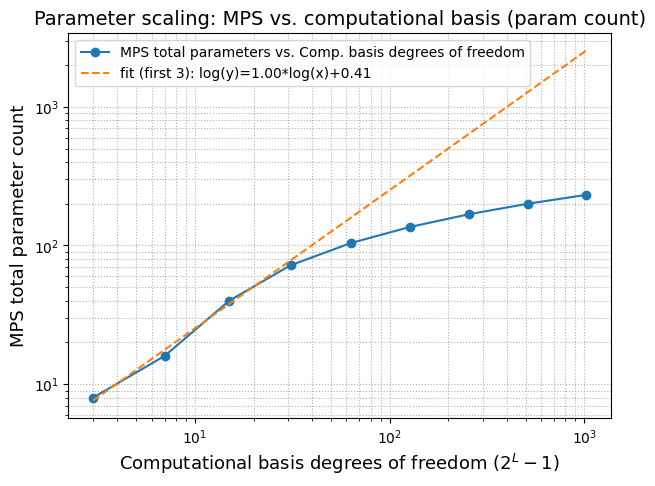

In [37]:

import matplotlib.pyplot as plt

L_vals = list(range(2, 11))
mps_param_counts = []
basis_counts = []

for L in tqdm(L_vals):  # Example: L from 2 to 10
    rand_mps = get_rand_mps(L=L, chi=4, dtype=np.complex128)
    tot_num_params = 0
    for i in range(L):
        tot_num_params += np.prod(rand_mps[i].shape)
    mps_param_counts.append(tot_num_params)
    basis_counts.append(2**L - 1)  # Number of real degrees of freedom in (normalized) state vector

# Fit a line (in log-log space) using only the first 8 values
from numpy import log10

# Restrict to the first 8 points
trunc = 3
x = np.array(basis_counts[:trunc])
y = np.array(mps_param_counts[:trunc])
logx = np.log10(x)
logy = np.log10(y)

# Fit line in log-log space
params = np.polyfit(logx, logy, 1)
a, b = params

# Plot + fit
plt.figure(figsize=(7, 5))
plt.plot(basis_counts, mps_param_counts, 'o-', label="MPS total parameters vs. Comp. basis degrees of freedom")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Computational basis degrees of freedom ($2^L-1$)", fontsize=13)
plt.ylabel("MPS total parameter count", fontsize=13)
plt.legend()
plt.title("Parameter scaling: MPS vs. computational basis (param count)", fontsize=14)
plt.grid(True, which="both", ls=":")
# Plot fit (on full x-range)
plt.plot(
    basis_counts,
    10 ** (a * np.log10(basis_counts) + b),
    '--',
    label=f"fit (first {trunc}): log(y)={a:.2f}*log(x)+{b:.2f}"
)
plt.legend()
plt.show()

